In [21]:
# import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

# gradient boosting libraries
import xgboost as xgb
# import lightgbm as lgb

In [3]:
# Load the dataset
data= pd.read_csv('Train_v2.csv')

In [4]:
# take a look at the data
data.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [6]:
data.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


In [7]:
data.isnull().sum()*100/len(data)

country                   0.0
year                      0.0
uniqueid                  0.0
bank_account              0.0
location_type             0.0
cellphone_access          0.0
household_size            0.0
age_of_respondent         0.0
gender_of_respondent      0.0
relationship_with_head    0.0
marital_status            0.0
education_level           0.0
job_type                  0.0
dtype: float64

In [8]:
data.duplicated().sum()*100/len(data)

np.float64(0.0)

In [9]:
data.columns

Index(['country', 'year', 'uniqueid', 'bank_account', 'location_type',
       'cellphone_access', 'household_size', 'age_of_respondent',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type'],
      dtype='object')

In [10]:

# Base loan amount
data["loan_amount"] = 5000

# Increase based on education
data.loc[data["education_level"] == "Secondary education", "loan_amount"] += 10000
data.loc[data["education_level"] == "Tertiary education", "loan_amount"] += 30000

# Increase based on job
data.loc[data["job_type"] == "Self employed", "loan_amount"] += 15000
data.loc[data["job_type"] == "Formally employed Private", "loan_amount"] += 25000

# Increase based on bank account
data.loc[data["bank_account"] == "Yes", "loan_amount"] += 20000

# Add randomness
data["loan_amount"] += np.random.randint(1000, 10000, size=len(data))

In [11]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical features:", numerical_features)

categorical_features = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_features)


Numerical features: ['year', 'household_size', 'age_of_respondent', 'loan_amount']
Categorical features: ['country', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


# visualization 

# categorical distribution 

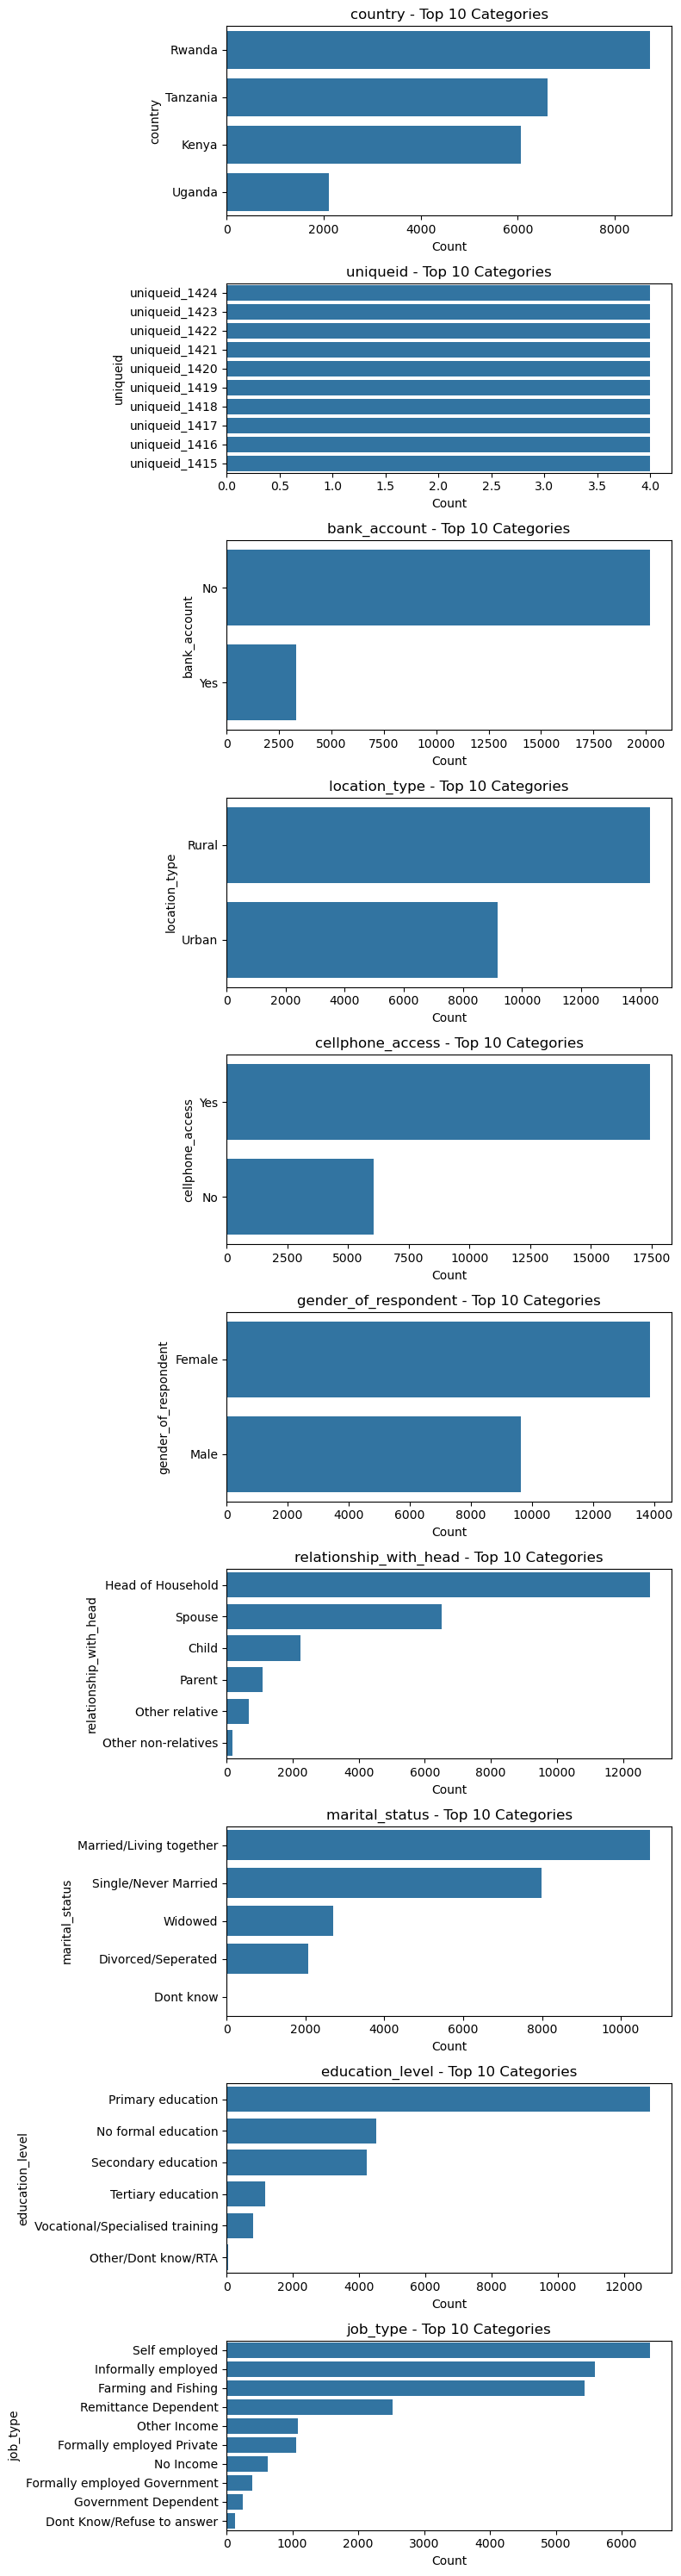

In [12]:
n_cat = len(categorical_features)

# Create subplots for categorical features
if n_cat > 0:
    fig, axes = plt.subplots(
        nrows=n_cat,
        figsize=(8, 3 * n_cat)
    )

    # Ensure axes is iterable when only one plot
    if n_cat == 1:
        axes = [axes]

    for ax, col in zip(axes, categorical_features):
        # Plot only top categories for speed
        top_counts = data[col].value_counts().head(10)

        sns.barplot(
            x=top_counts.values,
            y=top_counts.index,
            ax=ax
        )

        ax.set_title(f'{col} - Top 10 Categories')
        ax.set_xlabel("Count")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

# numerical distribution

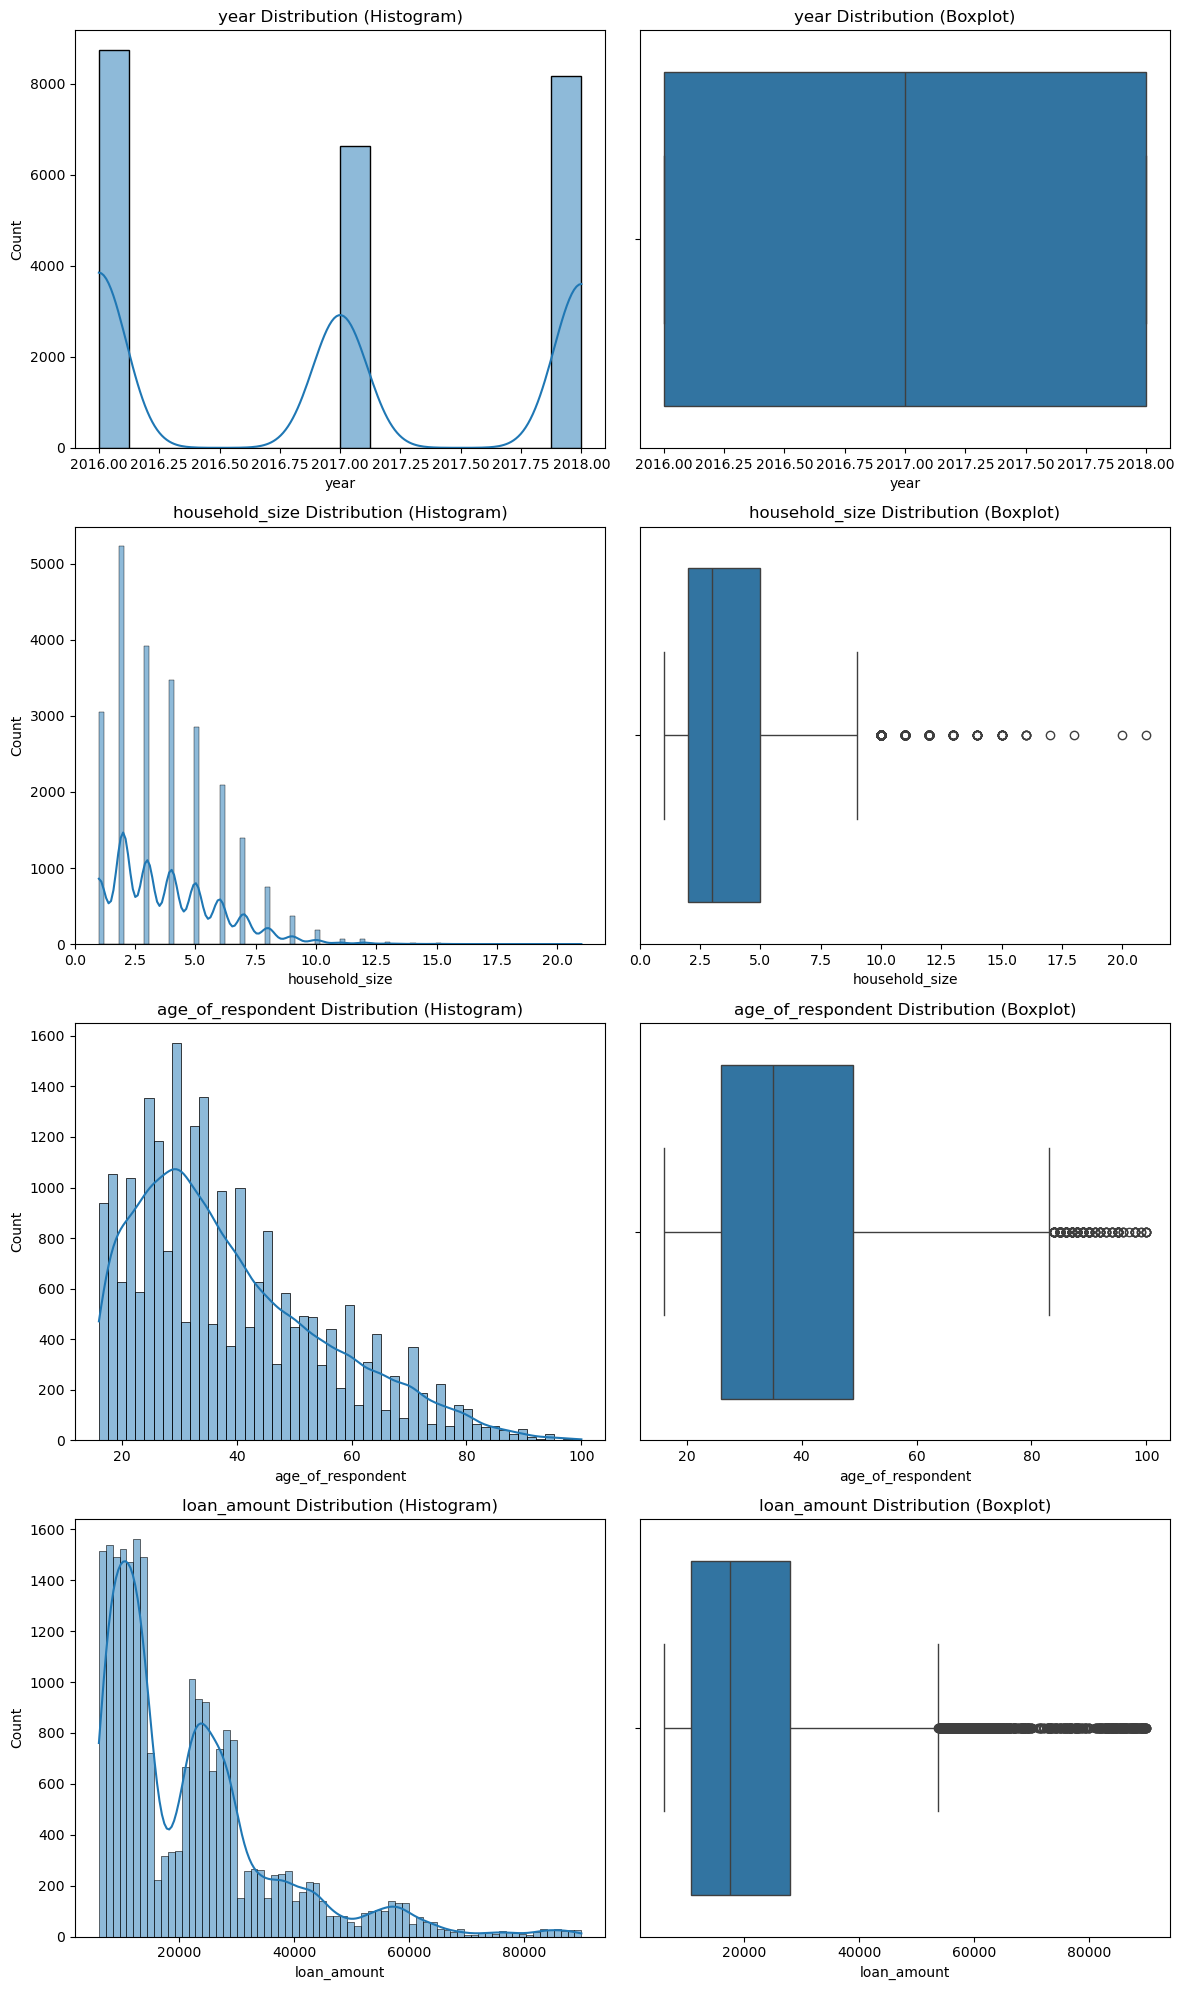

In [13]:
n_num = len(numerical_features)

# Create subplots for numerical features
if n_num > 0:
    fig, axes = plt.subplots(n_num, 2, figsize=(12, 5 * n_num))
    if n_num == 1:
        axes = [axes]
    for i, col in enumerate(numerical_features):
        sns.histplot(data[col], kde=True, ax=axes[i][0])
        axes[i][0].set_title(f'{col} Distribution (Histogram)')
        sns.boxplot(x=data[col], ax=axes[i][1])
        axes[i][1].set_title(f'{col} Distribution (Boxplot)')
    plt.tight_layout()
    plt.show()

# loan amount distribution 

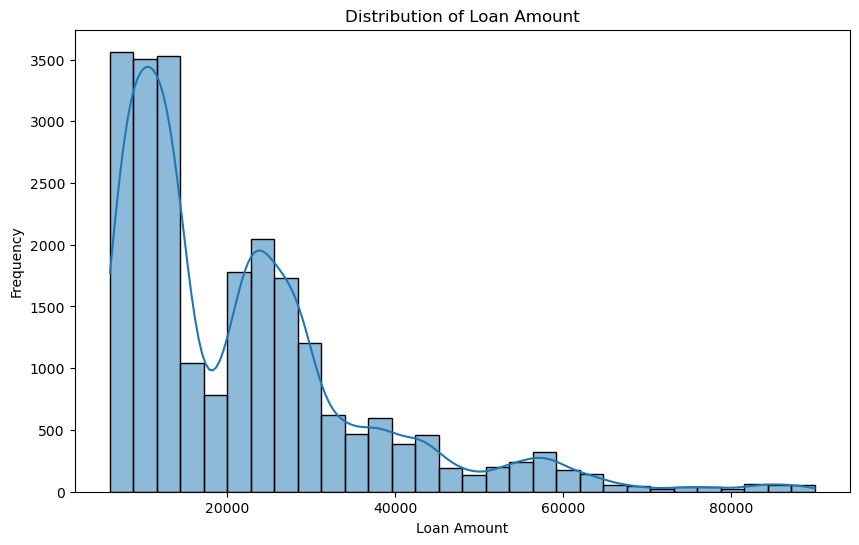

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data['loan_amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

# house size vs  loan amount 

Text(0, 0.5, 'House Size')

<Figure size 1000x600 with 0 Axes>

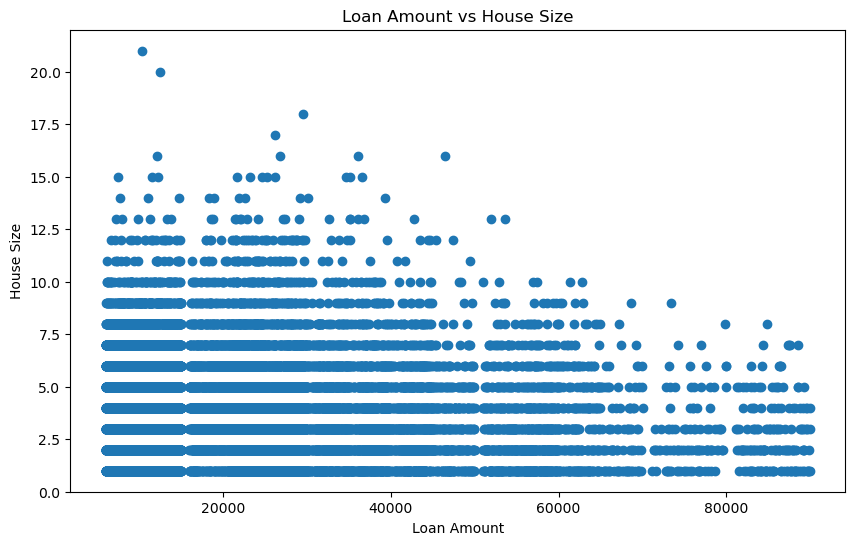

In [15]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.scatter(data['loan_amount'], data['household_size'])
plt.xlabel('Loan Amount')
plt.ylabel('Household Size')
plt.title('Loan Amount vs House Size')
plt.xlabel('Loan Amount')
plt.ylabel('House Size')   

<Figure size 1000x600 with 0 Axes>

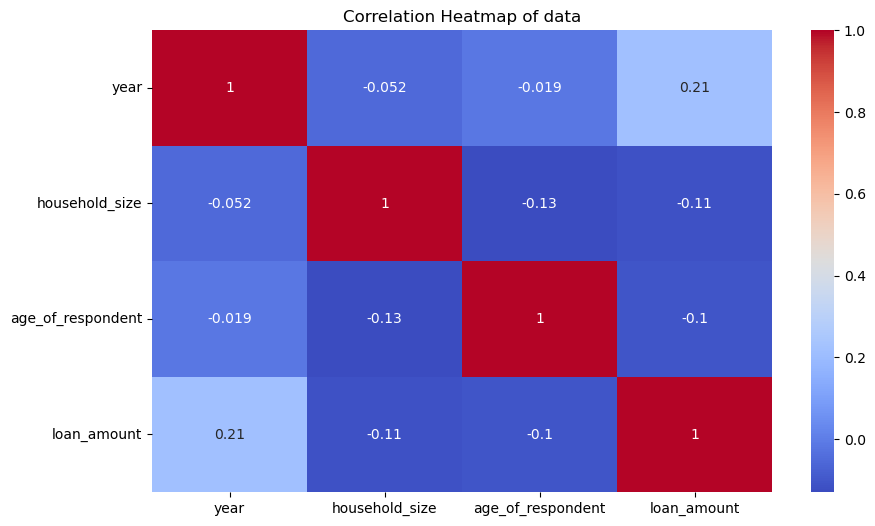

In [16]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of data')
plt.show()


## MODELING 

# feature selection 

In [17]:
X = data.drop(["loan_amount"], axis=1)

y = data["loan_amount"]

# one hot encoding

In [18]:
X = pd.get_dummies(X, drop_first=True)

# traing and testing 

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---1--- linear regression  base model



In [22]:
line_reg= LinearRegression()
line_reg.fit(X_train, y_train)
y_pred = line_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
msa= mean_squared_error(y_test, y_pred)

print(f"Linear Regression MSE: {mse:.2f}")
print(f"Linear Regression R²: {r2:.2f}")
print(f"Linear Regression MSA: {msa:.2f}")


Linear Regression MSE: 11348607.60
Linear Regression R²: 0.95
Linear Regression MSA: 11348607.60


# ---2---DECISION TREE MODEL

In [ ]:
dt=DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mase = mean_squared_error(y_test, y_pred)


print(f"Decision Tree MSE: {mse:.2f}")
print(f"Decision Tree R²: {r2:.2f}")
print(f"Decision Tree MASE: {mase:.2f}")



Decision Tree MSE: 6861953.89
Decision Tree R²: 0.97
Decision Tree MASE: 6861953.89
Decision Tree Accuracy: 0.00


# ---3---RANDOM FOREST MODEL

In [ ]:
rfm= RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rfm.fit(X_train, y_train)
y_pred = rfm.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mase = mean_squared_error(y_test, y_pred)


print(f"Random Forest MSE: {mse:.2f}")
print(f"Random Forest R²: {r2:.2f}")    
print(f"Random Forest MASE: {mase:.2f}")


Random Forest MSE: 6845267.26
Random Forest R²: 0.97
Random Forest MASE: 6845267.26
Random Forest Accuracy: 0.00


# ---4--- XGBOOST MODEL

In [27]:
xgbm = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgbm.fit(X_train, y_train)
y_pred = xgbm.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mase = mean_squared_error(y_test, y_pred)

print(f"XGBoost MSE: {mse:.2f}")
print(f"XGBoost R²: {r2:.2f}")
print(f"XGBoost MASE: {mase:.2f}")

XGBoost MSE: 6851525.00
XGBoost R²: 0.97
XGBoost MASE: 6851525.00
